In [1]:
%load_ext autoreload
%autoreload 2

# AvgSA([0, 6]) -- Post-Processing (Stage 2)

Loads `AvgSA_06_final_ensembles.pickle` from the Stage-1 compute notebook and regenerates the result pickles, plots and download/convert CSVs. Runs in seconds; raises `StaleCacheError` if the artifact's inputs changed.

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd_project.config.config import load_config
from phd_project.scripts.cache_utils import fingerprint, verify

cfg = load_config()

# paths
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / "gcim_dist_AvgSA_06.pickle"
final_ensembles_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_final_ensembles.pickle"
esm_records_to_download_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_summary_esm_records_selected.csv"
ngasub_records_to_download_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_summary_ngasub_records_selected.csv"
disagg_stats_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
disagg_data_fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"

# load the Stage-1 canonical artifact + the cheap inputs needed for post-processing
with open(final_ensembles_fp, "rb") as f:
    final_ensembles = pickle.load(f)
with open(gcim_dist_fp, "rb") as f:
    gcim_dists = pickle.load(f)
with open(disagg_stats_fp, "rb") as f:
    disagg_stats = pickle.load(f)

# Refuse to post-process a stale artifact: confirm the source files that produced
# final_ensembles are unchanged (hashes only -- nothing heavy is loaded).
verify(final_ensembles_fp, fingerprint(
    gm_db_file=cfg["proc_data"]["gm_database"],
    gcim_file=gcim_dist_fp,
    disagg_data_file=disagg_data_fp,
    disagg_stats_file=disagg_stats_fp,
    site_model_file=cfg["hazard_models"]["eshm20_AvgSA_site_model_all"],
))
print("Artifact provenance verified.")

Artifact provenance verified.


## Save per-(site, poe) ensembles + surface record identifiers

In [3]:
# Save the best ensembles in the results folder
RESULT_FOLDER = cfg["results"]["AvgSA_06_record_selection"]

poe_2_stripe_num_map = {poe:ii+1 for ii, poe in enumerate(sorted(disagg_stats["poe"].unique(), reverse=True))}

for (site, poe), ensemble in final_ensembles.items():

    if not ensemble["ks_passed"]:
        print(f"No valid ensemble: Site {site} - poe = {poe}")
        continue
    
    tag = f"site_{site}__stripe_{poe_2_stripe_num_map[poe]}"

    # Stripe identifiers required by standes.analysis.msa.read_stripe_selection
    ensemble["poe"] = float(poe)
    # annual PoE -> return period via the Poisson/exponential model:
    # poe = 1 - exp(-1/rtp)  =>  rtp = -1 / ln(1 - poe)
    ensemble["rtp"] = round(-1.0 / np.log(1.0 - poe))
    
    # Add the gcim_quantiles from the result
    ensemble["gcim_quantiles"] = gcim_dists[(site, poe)]["stats"]

    # calculate the trt %'s
    trt_stats = pd.DataFrame(
        ensemble["recs"].groupby(("metadata", "trt")).size())
    trt_stats.columns = ["count"]
    trt_stats["proportions"] = np.round(trt_stats["count"] / \
                                        trt_stats["count"].sum(), 3)
    ensemble["trt_stats"] = trt_stats

    # Surface RSN + a stable record identifier and JSON filename per record.
    recs = ensemble["recs"]
    is_ngasub = recs[("metadata", "database")] == "NGASub"

    # RSN: already present as metadata.index for NGASub; NA for ESM.
    recs[("metadata", "RSN")] = (
        recs[("metadata", "index")].astype("string").where(is_ngasub)
    )

    # record_identifier: ESM uses event/station/location; NGASub uses the RSN.
    esm_id = (
        recs[("metadata", "event_id")].astype(str) + "_"
        + recs[("metadata", "station_code")].astype(str) + "_"
        + recs[("metadata", "location_code")].astype(str)
    )
    recs[("metadata", "record_identifier")] = esm_id.where(
        ~is_ngasub, recs[("metadata", "index")].astype(str)
    )

    # filename: {record_identifier}__{component}.json
    recs[("metadata", "filename")] = (
        recs[("metadata", "record_identifier")].astype(str)
        + "__" + recs[("metadata", "component")].astype(str) + ".json"
    )

    with open(RESULT_FOLDER / f"{tag}__gm_selection.pickle", "wb") as file:
        pickle.dump(ensemble, file)
            

## Identify the number of unique records and unique events across all sites

In [4]:
# combine all ensembles into one dataframe
rec_dfs = []
for e in final_ensembles.values():
    rec_dfs.append(e["recs"])

all_recs = pd.concat(rec_dfs, axis=0)
events = all_recs.groupby(("metadata", "event_id")).size().sort_values(ascending=False)
events = pd.DataFrame(events, columns=["count"])
events["cum_sum"] = events["count"].cumsum() 
events["cum_%"] = np.round(events["cum_sum"] / events["count"].sum(), 4)

recs_and_events = all_recs.reset_index().groupby([("metadata", "event_id"), "index"])\
    .size().sort_values(ascending=False)
recs_and_events = pd.DataFrame(recs_and_events, columns=["count"])
recs_and_events["cum_sum"] = recs_and_events["count"].cumsum() 
recs_and_events["cum_%"] = np.round(recs_and_events["cum_sum"] / recs_and_events["count"].sum(), 4)
recs_and_events

print(f"Number of unique events: {len(events)}")
print(f"Number of unique records: {len(recs_and_events)}")
print(f"Maximum number of times a record was selected: {recs_and_events["count"].iloc[0]} ({recs_and_events["count"].iloc[0] / len(all_recs)*100:.2f} %)")

Number of unique events: 256
Number of unique records: 2417
Maximum number of times a record was selected: 163 (1.51 %)


In [5]:
recs_and_events

count  cum_sum   cum_%
(metadata, event_id)  index                         
IT-2012-0011          36898     163      163  0.0151
EMSC-20160824_0000006 7130      158      321  0.0297
EMSC-20161030_0000029 30462     154      475  0.0440
TK-1999-0415          40095     133      608  0.0563
IT-2009-0009          33799     132      740  0.0685
...                             ...      ...     ...
7000049               123874      1    10796  0.9996
                      123867      1    10797  0.9997
TK-2007-0024          40581       1    10798  0.9998
TK-2006-0107          20211       1    10799  0.9999
TK-2005-0054          20100       1    10800  1.0000

[2417 rows x 3 columns]

(0.0, 267.75)

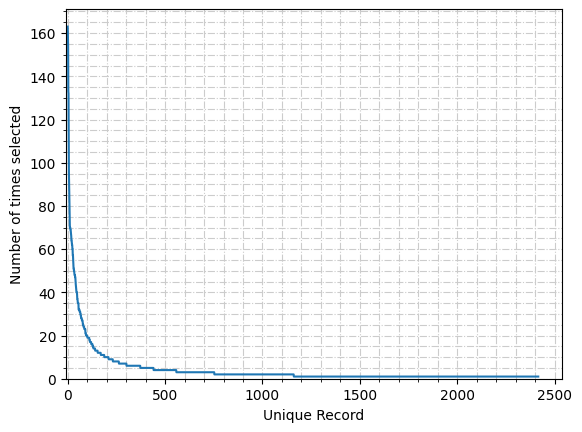

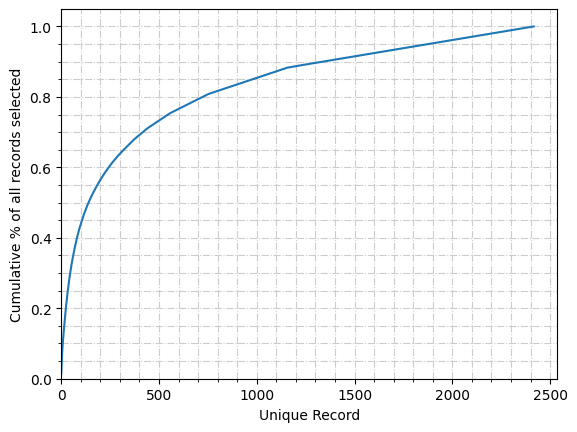

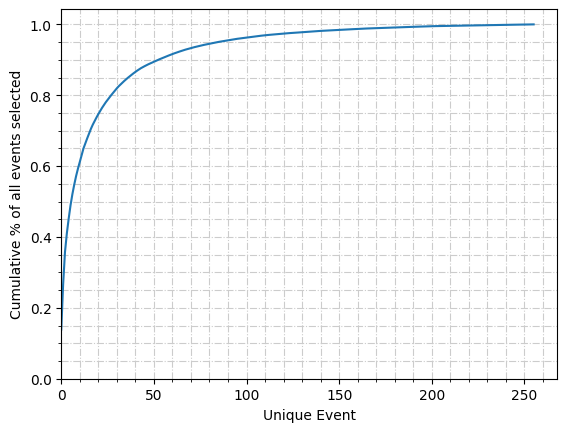

In [6]:
fig, ax3 = plt.subplots()
ax3.plot(recs_and_events["count"].to_numpy())
ax3.grid(True, which="both", ls="-.", color="0.8")
ax3.minorticks_on()
ax3.set_xlabel("Unique Record")
ax3.set_ylabel("Number of times selected")
ax3.set_ylim(0)
ax3.set_xlim(-10)

fig, ax1 = plt.subplots()
ax1.plot(recs_and_events["cum_%"].to_numpy())
ax1.grid(True, which="both", ls="-.", color="0.8")
ax1.minorticks_on()
ax1.set_xlabel("Unique Record")
ax1.set_ylabel("Cumulative % of all records selected")
ax1.set_ylim(0)
ax1.set_xlim(0)

fig, ax2 = plt.subplots()
ax2.plot(events["cum_%"].to_numpy())
ax2.grid(True, which="both", ls="-.", color="0.8")
ax2.minorticks_on()
ax2.set_xlabel("Unique Event")
ax2.set_ylabel("Cumulative % of all events selected")
ax2.set_ylim(0)
ax2.set_xlim(0)


## Records to download / convert

In [7]:
cols_to_keep = [("metadata", "event_id"), ("metadata", "station_code"), ("metadata", "location_code")]
unique_esm_records = all_recs[all_recs[("metadata", "database")] == "ESM"]\
                     .drop_duplicates(subset=cols_to_keep)
unique_esm_records = unique_esm_records[cols_to_keep].reset_index(drop=True)
esm_records_to_download = unique_esm_records
esm_records_to_download.to_csv(esm_records_to_download_fp, index=False)

In [8]:
# For the NGASub records we need the NGAsubRSN for each combination of event_id and station_code
NGASub_records = all_recs[all_recs[("metadata", "database")] == "NGASub"]
unique_NGASub_id_counts = NGASub_records.groupby(
    [("metadata", "event_id"), ("metadata", "station_code")]).size().sort_values(ascending=False)
unique_NGASub_id_counts = unique_NGASub_id_counts.rename("count")

# load the NGASub database
ngasub_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"
ngasub_db = pd.read_csv(ngasub_fp, header=0, encoding="cp1252", dtype=str)
new_index = list(ngasub_db[["NGAsubEQID", "NGAsubSSN"]].itertuples(index=False, name=None))
ngasub_db.index = new_index
ngasub_db = ngasub_db["NGAsubRSN"]

# RSNs to download
rsns_to_download = ngasub_db.loc[unique_NGASub_id_counts.index]
rsns_to_download = pd.concat([rsns_to_download, unique_NGASub_id_counts], axis=1)
rsns_to_download.to_csv(ngasub_records_to_download_fp, index=False)

In [9]:
# Per-campaign record-conversion list (record_identifier, component, database)
# for the AT2/HDF5 -> JSON converters. Combined across campaigns in
# wp1pt3pt8i-organise_records_to_download.
records_to_convert = (
    all_recs["metadata"][["record_identifier", "component", "database"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
records_to_convert.to_csv(
    cfg["proc_data"]["gm_selection"] / "AvgSA_06_records_to_convert.csv",
    index=False,
)
